<a href="https://colab.research.google.com/github/AreHand/Central-Java-Health-Workers-2022/blob/main/analisis_nakes_jateng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install library yang dibutuhkan
!pip install pandas matplotlib seaborn --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")

✅ Library siap!


In [6]:
# ============================================
# CELL 2 — Upload & Load Data
# ============================================
from google.colab import files
import pandas as pd

# Upload file nakes_jateng_clean.csv
uploaded = files.upload()

# Load data — SUDAH BERSIH, langsung bisa dibaca
df = pd.read_csv('nakes_jateng_clean.csv')

print(f"✅ Data berhasil dimuat!")
print(f"   Jumlah daerah : {len(df)}")
print(f"   Jumlah kolom  : {len(df.columns)}")
print()
df.head()

Saving nakes_jateng_clean.csv to nakes_jateng_clean (1).csv
✅ Data berhasil dimuat!
   Jumlah daerah : 35
   Jumlah kolom  : 10



,TIPE,KABUPATEN_KOTA,JUMLAH_PENDUDUK,JUMLAH_TENAGA_GIZI,JUMLAH_TENAGA_FARMASI,JUMLAH_BIDAN,JUMLAH_PERAWAT,JUMLAH_DOKTER_GIGI,JUMLAH_DOKTER_SPESIALIS,JUMLAH_DOKTER_UMUM
0,Kab,Kab.Cilacap,1988622,93,369,1264,2140,58,107,289
1,Kab,Kab.Banyumas,1806013,157,566,1325,3558,128,349,566
2,Kab,Kab.Purbalingga,1019840,58,264,733,1355,36,52,180
3,Kab,Kab.Banjarnegara,1038718,97,225,796,1071,46,44,150
4,Kab,Kab.Kebumen,1376825,93,438,1244,1965,60,114,299


In [7]:
# ============================================
# CELL 3 — Jawab 7 Pertanyaan
# ============================================

# Q1: Total Tenaga Kesehatan
nakes_cols = ['JUMLAH_TENAGA_GIZI','JUMLAH_TENAGA_FARMASI','JUMLAH_BIDAN',
              'JUMLAH_PERAWAT','JUMLAH_DOKTER_GIGI',
              'JUMLAH_DOKTER_SPESIALIS','JUMLAH_DOKTER_UMUM']
df['TOTAL_NAKES'] = df[nakes_cols].sum(axis=1)
print(f"1️⃣  Total Tenaga Kesehatan : {int(df['TOTAL_NAKES'].sum()):,} orang")

# Q2: Total Penduduk
print(f"2️⃣  Total Penduduk         : {int(df['JUMLAH_PENDUDUK'].sum()):,} jiwa")

# Q3: Total Kabupaten/Kota
print(f"3️⃣  Total Kabupaten/Kota   : {len(df)} daerah")
print(f"    - Kabupaten            : {len(df[df['TIPE']=='Kab'])}")
print(f"    - Kota                 : {len(df[df['TIPE']=='Kota'])}")

# Q4: Rata-rata Dokter Umum
print(f"4️⃣  Rata-rata Dokter Umum  : {df['JUMLAH_DOKTER_UMUM'].mean():.2f} per daerah")

# Q5 & Q6: Rasio Dokter
df['RASIO_DOKTER'] = (df['JUMLAH_DOKTER_UMUM'] / df['JUMLAH_PENDUDUK']) * 1000
cukup = df[df['RASIO_DOKTER'] >= 1].sort_values('RASIO_DOKTER', ascending=False)
print(f"\n5️⃣  Daerah rasio dokter mencukupi (≥1 per 1000 penduduk):")
for _, r in cukup.iterrows():
    print(f"    ✅ {r['KABUPATEN_KOTA']:<20} rasio: {r['RASIO_DOKTER']:.3f}")

print(f"\n6️⃣  Jumlah daerah mencukupi: {len(cukup)} dari {len(df)} ({len(cukup)/len(df)*100:.1f}%)")

# Q7: Dokter Spesialis di Kota
kota = df[df['TIPE']=='Kota'].sort_values('JUMLAH_DOKTER_SPESIALIS', ascending=False)
print(f"\n7️⃣  Dokter Spesialis di Kota-kota:")
for _, r in kota.iterrows():
    print(f"    🏥 {r['KABUPATEN_KOTA']:<20}: {int(r['JUMLAH_DOKTER_SPESIALIS'])} spesialis")

1️⃣  Total Tenaga Kesehatan : 124,757 orang
2️⃣  Total Penduduk         : 37,032,410 jiwa
3️⃣  Total Kabupaten/Kota   : 35 daerah
    - Kabupaten            : 29
    - Kota                 : 6
4️⃣  Rata-rata Dokter Umum  : 309.14 per daerah

5️⃣  Daerah rasio dokter mencukupi (≥1 per 1000 penduduk):
    ✅ Kota Surakarta       rasio: 1.648
    ✅ Kota Magelang        rasio: 1.479
    ✅ Kota Semarang        rasio: 1.283

6️⃣  Jumlah daerah mencukupi: 3 dari 35 (8.6%)

7️⃣  Dokter Spesialis di Kota-kota:
    🏥 Kota Semarang       : 952 spesialis
    🏥 Kota Surakarta      : 686 spesialis
    🏥 Kota Magelang       : 135 spesialis
    🏥 Kota Salatiga       : 88 spesialis
    🏥 Kota Tegal          : 60 spesialis
    🏥 Kota Pekalongan     : 59 spesialis


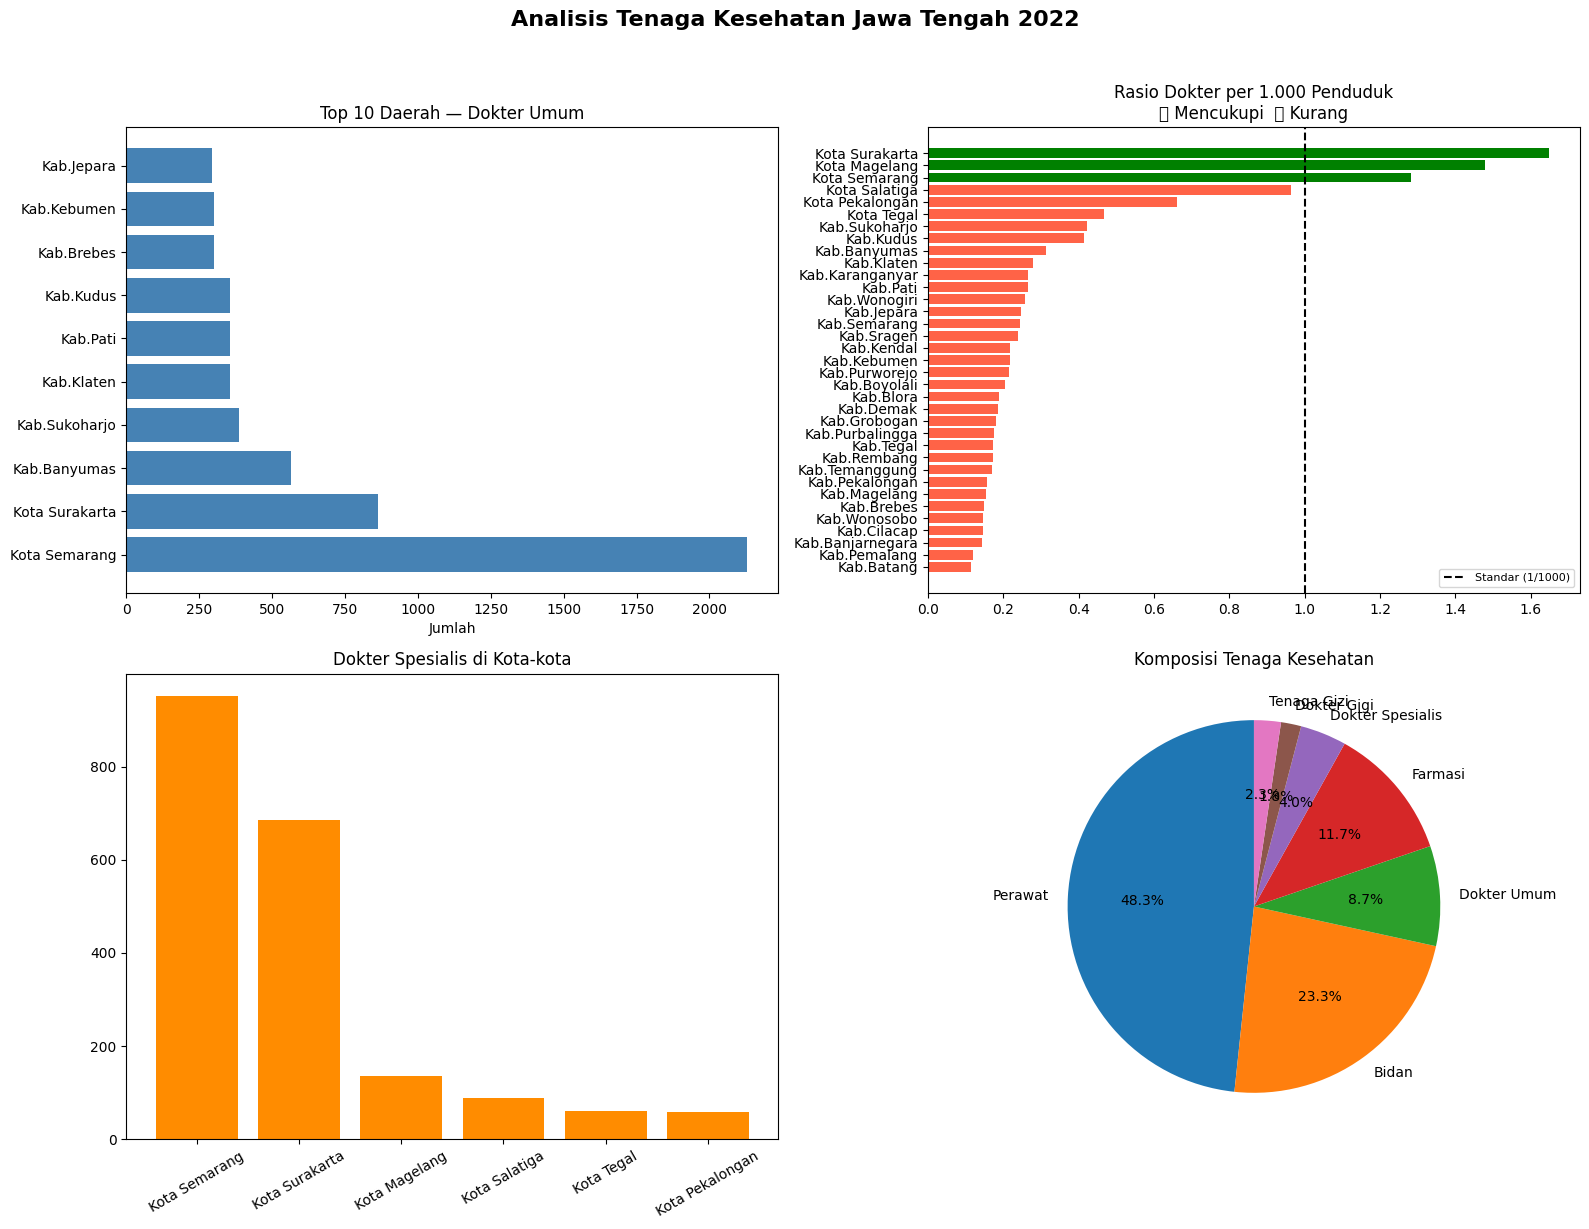

✅ Chart tersimpan sebagai chart_nakes_jateng.png


In [8]:
# ============================================
# CELL 4 — Visualisasi 4 Chart
# ============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Tenaga Kesehatan Jawa Tengah 2022',
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1: Top 10 Dokter Umum
top10 = df.nlargest(10, 'JUMLAH_DOKTER_UMUM')
axes[0,0].barh(top10['KABUPATEN_KOTA'], top10['JUMLAH_DOKTER_UMUM'], color='steelblue')
axes[0,0].set_title('Top 10 Daerah — Dokter Umum')
axes[0,0].set_xlabel('Jumlah')

# Chart 2: Rasio Dokter semua daerah
df_sorted = df.sort_values('RASIO_DOKTER')
colors = ['green' if x >= 1 else 'tomato' for x in df_sorted['RASIO_DOKTER']]
axes[0,1].barh(df_sorted['KABUPATEN_KOTA'], df_sorted['RASIO_DOKTER'], color=colors)
axes[0,1].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='Standar (1/1000)')
axes[0,1].set_title('Rasio Dokter per 1.000 Penduduk\n🟢 Mencukupi  🔴 Kurang')
axes[0,1].legend(fontsize=8)

# Chart 3: Spesialis di Kota
kota_sorted = df[df['TIPE']=='Kota'].sort_values('JUMLAH_DOKTER_SPESIALIS', ascending=False)
axes[1,0].bar(kota_sorted['KABUPATEN_KOTA'],
              kota_sorted['JUMLAH_DOKTER_SPESIALIS'], color='darkorange')
axes[1,0].set_title('Dokter Spesialis di Kota-kota')
axes[1,0].tick_params(axis='x', rotation=30)

# Chart 4: Pie komposisi
pie_data = {
    'Perawat': df['JUMLAH_PERAWAT'].sum(),
    'Bidan': df['JUMLAH_BIDAN'].sum(),
    'Dokter Umum': df['JUMLAH_DOKTER_UMUM'].sum(),
    'Farmasi': df['JUMLAH_TENAGA_FARMASI'].sum(),
    'Dokter Spesialis': df['JUMLAH_DOKTER_SPESIALIS'].sum(),
    'Dokter Gigi': df['JUMLAH_DOKTER_GIGI'].sum(),
    'Tenaga Gizi': df['JUMLAH_TENAGA_GIZI'].sum()
}
axes[1,1].pie(pie_data.values(), labels=pie_data.keys(),
              autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Komposisi Tenaga Kesehatan')

plt.tight_layout()
plt.savefig('chart_nakes_jateng.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan sebagai chart_nakes_jateng.png")